In [1]:
!pip -q install kagglehub

In [ ]:
!pip -q install torchmetrics

In [ ]:
!pip install scikit-image

In [4]:
import kagglehub
import os
import re
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import numpy as np
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import random
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import time
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from torchmetrics.classification import MultilabelAUROC
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from skimage.measure import shannon_entropy
import cv2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

In [ ]:
DATA_ROOT = kagglehub.dataset_download("ashery/chexpert")

train_df = pd.read_csv(f"{DATA_ROOT}/train.csv")
valid_df = pd.read_csv(f"{DATA_ROOT}/valid.csv")

def build_full_path(rel_path: str) -> str:
    corrected = rel_path.replace("CheXpert-v1.0-small/", "")
    return os.path.join(DATA_ROOT, corrected)

train_df["FullPath"] = train_df["Path"].apply(build_full_path)
valid_df["FullPath"] = valid_df["Path"].apply(build_full_path)



In [7]:

train_df = train_df[train_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)
valid_df = valid_df[valid_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)


In [8]:

SEED = 42

def extract_patient_id(path: str) -> str:

    m = re.search(r"(patient\d+)", str(path))
    if not m:
        raise ValueError(f"Could not parse patient id from Path: {path}")
    return m.group(1)


train_df = train_df.copy()
valid_df = valid_df.copy()

train_df["patient_id"] = train_df["Path"].apply(extract_patient_id)
valid_df["patient_id"] = valid_df["Path"].apply(extract_patient_id)

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df["patient_id"]))

train_df_train = train_df.iloc[train_idx].reset_index(drop=True)
train_df_val   = train_df.iloc[val_idx].reset_index(drop=True)


test_df = valid_df.reset_index(drop=True)


In [9]:
SPLIT_DIR = "/content/drive/MyDrive/FYP_CheXpert/splits_fyp"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df_train.to_csv(os.path.join(SPLIT_DIR, "train_df_train.csv"), index=False)
train_df_val.to_csv(os.path.join(SPLIT_DIR, "train_df_val.csv"), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, "test_df.csv"), index=False)

print("Saved split CSVs to:", SPLIT_DIR)

Saved split CSVs to: /content/drive/MyDrive/FYP_CheXpert/splits_fyp


In [10]:
def summarize(df, name):
    print(f"{name}: {len(df):,} images | {df['patient_id'].nunique():,} patients")

summarize(train_df_train, "train")
summarize(train_df_val,   "val")
summarize(test_df,        "test")

train: 171,927 images | 58,080 patients
val: 19,100 images | 6,454 patients
test: 202 images | 200 patients


In [11]:
TARGET_LABELS = ["Lung Opacity", "Pleural Effusion", "Edema", "Cardiomegaly", "Pneumothorax"]

def make_targets_and_mask(df: pd.DataFrame, target_labels):
    y_raw = df[target_labels].to_numpy()

    mask = np.isin(y_raw, [0, 1]).astype(np.float32)

    y = (y_raw == 1).astype(np.float32)

    return y, mask

y_train, m_train = make_targets_and_mask(train_df_train, TARGET_LABELS)
y_val,   m_val   = make_targets_and_mask(train_df_val,   TARGET_LABELS)
y_test,  m_test  = make_targets_and_mask(test_df,        TARGET_LABELS)

print("Train valid rate:", m_train.mean(axis=0))
print("Val valid rate:  ", m_val.mean(axis=0))
print("Test valid rate: ", m_test.mean(axis=0))

Train valid rate: [0.5197264  0.53505266 0.34385523 0.16319717 0.34297115]
Val valid rate:   [0.5186911  0.53445023 0.33884817 0.16732985 0.34293193]
Test valid rate:  [1. 1. 1. 1. 1.]


In [ ]:
def build_full_path(rel_path: str) -> str:

    corrected = rel_path.replace("CheXpert-v1.0-small/", "")
    return os.path.join(DATA_ROOT, corrected)

for df in [train_df_train, train_df_val, test_df]:
    df["FullPath"] = df["Path"].apply(build_full_path)

for p in train_df_train["FullPath"].head(5).tolist():
    print(p, "exists:", os.path.exists(p))

In [13]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [14]:
class CheXpertDatasetMasked(Dataset):

    def __init__(self, df: pd.DataFrame, y: np.ndarray, m: np.ndarray, transform=None, path_col: str="FullPath"):
        self.df = df.reset_index(drop=True)
        self.y = y
        self.m = m
        self.transform = transform
        self.path_col = path_col

        assert len(self.df) == len(self.y) == len(self.m)
        assert self.path_col in self.df.columns, f"Missing column {self.path_col}. Available: {list(self.df.columns)}"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, self.path_col]

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            x = self.transform(img)
        else:
            x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0

        y = torch.from_numpy(self.y[idx]).float()
        m = torch.from_numpy(self.m[idx]).float()
        return x, y, m

In [15]:
train_ds = CheXpertDatasetMasked(train_df_train, y_train, m_train, transform=train_transform, path_col="FullPath")
val_ds   = CheXpertDatasetMasked(train_df_val,   y_val,   m_val,   transform=valid_transform, path_col="FullPath")
test_ds  = CheXpertDatasetMasked(test_df,        y_test,  m_test,  transform=valid_transform, path_col="FullPath")

In [16]:
BATCH_SIZE = 64
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

class ChexpertDenseNet121(nn.Module):
    def __init__(self, num_labels=5, pretrained=True, freeze_backbone=True):
        super().__init__()
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        self.backbone = models.densenet121(weights=weights)
        self.backbone.classifier = nn.Linear(self.backbone.classifier.in_features, num_labels)

        if freeze_backbone:
            for p in self.backbone.features.parameters():
                p.requires_grad = False
            for p in self.backbone.classifier.parameters():
                p.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

device: cuda


In [ ]:
NUM_LABELS = len(TARGET_LABELS)

model = ChexpertDenseNet121(num_labels=NUM_LABELS, pretrained=True, freeze_backbone=True).to(device)

In [19]:
from google.colab import files
files.upload()

{}

In [ ]:
CKPT_PATH = "/content/baseline_v1_masked_frozen.pt"

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
print("Loaded:", CKPT_PATH)

In [ ]:

def set_trainable_v2(model):

    for p in model.parameters():
        p.requires_grad = False


    for p in model.backbone.classifier.parameters():
        p.requires_grad = True


    for p in model.backbone.features.transition3.parameters():
        p.requires_grad = True
    for p in model.backbone.features.denseblock4.parameters():
        p.requires_grad = True
    for p in model.backbone.features.norm5.parameters():
        p.requires_grad = True

set_trainable_v2(model)


trainable_names = [n for n,p in model.named_parameters() if p.requires_grad]
print("Trainable tensors:", len(trainable_names))
print("First trainable names:")
for n in trainable_names[:25]:
    print(" -", n)

print("\nTrainable param count:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

In [ ]:
pos = (y_train * m_train).sum(axis=0)
neg = ((1 - y_train) * m_train).sum(axis=0)

pos_weight = torch.tensor(neg / (pos + 1e-6), dtype=torch.float32, device=device)
print("pos_weight:", pos_weight.detach().cpu().numpy())

In [ ]:
def masked_bce_with_logits(logits, targets, mask, pos_weight=None):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    denom = mask.sum().clamp_min(1.0)
    return loss.sum() / denom

In [ ]:
LR_HEAD = 1e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4

head_params = list(model.backbone.classifier.parameters())

backbone_params = []
backbone_params += list(model.backbone.features.transition3.parameters())
backbone_params += list(model.backbone.features.denseblock4.parameters())
backbone_params += list(model.backbone.features.norm5.parameters())

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": LR_BACKBONE},
        {"params": head_params, "lr": LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY
)

print("Optimizer groups:")
print(" - backbone lr:", optimizer.param_groups[0]["lr"], "n_params:", sum(p.numel() for p in backbone_params))
print(" - head lr:", optimizer.param_groups[1]["lr"], "n_params:", sum(p.numel() for p in head_params))

In [ ]:
def masked_macro_auroc(probs_np, targets_np, masks_np):

    per_label_auc = []
    C = targets_np.shape[1]
    for c in range(C):
        valid = masks_np[:, c] == 1
        y_true = targets_np[valid, c]
        y_score = probs_np[valid, c]
        if len(np.unique(y_true)) < 2:
            per_label_auc.append(np.nan)
        else:
            per_label_auc.append(roc_auc_score(y_true, y_score))
    return float(np.nanmean(per_label_auc)), per_label_auc

def evaluate_val(model, loader, device):
    model.eval()
    all_probs, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for xb, yb, mb in tqdm(loader, desc="eval", leave=False):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)

            logits = model(xb)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.detach().cpu())
            all_targets.append(yb.detach().cpu())
            all_masks.append(mb.detach().cpu())

    probs_np = torch.cat(all_probs, dim=0).numpy()
    targets_np = torch.cat(all_targets, dim=0).numpy()
    masks_np = torch.cat(all_masks, dim=0).numpy()

    macro_auc, per_label_auc = masked_macro_auroc(probs_np, targets_np, masks_np)
    return macro_auc, per_label_auc

In [ ]:
def train_masked(
    model, train_loader, val_loader, optimizer, device, pos_weight,
    epochs=3
):
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()


        model.train()
        train_loss_sum = 0.0
        train_steps = 0

        for xb, yb, mb in tqdm(train_loader, desc=f"train {epoch}/{epochs}", leave=False):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = masked_bce_with_logits(logits, yb, mb, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.detach().cpu())
            train_steps += 1

        train_loss = train_loss_sum / max(train_steps, 1)

        model.eval()
        val_loss_sum = 0.0
        val_steps = 0
        with torch.no_grad():
            for xb, yb, mb in tqdm(val_loader, desc=f"val {epoch}/{epochs}", leave=False):
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                mb = mb.to(device, non_blocking=True)

                logits = model(xb)
                vloss = masked_bce_with_logits(logits, yb, mb, pos_weight=pos_weight)

                val_loss_sum += float(vloss.detach().cpu())
                val_steps += 1

        val_loss = val_loss_sum / max(val_steps, 1)


        val_macro_auc, val_per_label_auc = evaluate_val(model, val_loader, device)

        dt_min = (time.time() - t0) / 60
        print(
            f"Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_macro_AUROC={val_macro_auc:.4f} | {dt_min:.1f} min"
        )


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        print("Restored best model. Best val_loss:", best_val_loss)

    return model

In [ ]:
EPOCHS = 3
model = train_masked(model, train_loader, val_loader, optimizer, device, pos_weight, epochs=EPOCHS)

In [ ]:
def evaluate_test_masked(model, test_loader, device, target_labels):
    model.eval()

    all_probs, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for xb, yb, mb in tqdm(test_loader, desc="Test evaluation (masked)"):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)

            logits = model(xb)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.detach().cpu())
            all_targets.append(yb.detach().cpu())
            all_masks.append(mb.detach().cpu())

    probs_np   = torch.cat(all_probs, dim=0).numpy()
    targets_np = torch.cat(all_targets, dim=0).numpy()
    masks_np   = torch.cat(all_masks, dim=0).numpy()

    per_label_auc = []
    for c in range(targets_np.shape[1]):
        valid = masks_np[:, c] > 0.5
        y_true = targets_np[valid, c]
        y_score = probs_np[valid, c]


        if y_true.size == 0 or len(np.unique(y_true)) < 2:
            per_label_auc.append(np.nan)
        else:
            per_label_auc.append(roc_auc_score(y_true, y_score))

    macro_auc = np.nanmean(per_label_auc)

    print("\nTest Macro AUROC (masked):", float(macro_auc))
    print("\nPer-label AUROC (masked):")
    for name, auc in zip(target_labels, per_label_auc):
        print(f"{name:18s}: {auc:.4f}")

    print("\nValid test samples per label:")
    for name, cnt in zip(target_labels, masks_np.sum(axis=0).astype(int)):
        print(f"{name:18s}: {cnt}")

    return float(macro_auc), [float(x) if not np.isnan(x) else None for x in per_label_auc]

test_macro_auc_masked, test_per_label_auc_masked = evaluate_test_masked(
    model, test_loader, device, TARGET_LABELS
)

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

CKPT_PATH = "v2_masked_finetune_db4_t3_norm5_20260305_015938.pt"

assert CKPT_PATH is not None, "Set CKPT_PATH to your FT1 checkpoint file."

state = torch.load(CKPT_PATH, map_location="cpu")

if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

missing, unexpected = model.load_state_dict(state, strict=False)

print("Loaded checkpoint:", CKPT_PATH)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
if len(missing) < 30 and len(unexpected) < 30:
    print("Missing examples:", missing[:10])
    print("Unexpected examples:", unexpected[:10])

model.eval()

In [ ]:
out = evaluate_test_masked(model, test_loader, device, TARGET_LABELS)

if isinstance(out, tuple) and len(out) == 3:
    test_macro_auc, test_per_label_auc, test_valid_counts = out
elif isinstance(out, tuple) and len(out) == 2:
    test_macro_auc, test_per_label_auc = out
    test_valid_counts = None
else:
    raise ValueError(f"Unexpected return from evaluate_test_masked: {type(out)}")

print("\nLOCKED MODEL TEST macro AUROC:", float(test_macro_auc))
print("Per-label AUROC:")
for name, auc in zip(TARGET_LABELS, test_per_label_auc):
    print(f"{name:18s}: {float(auc):.4f}")

if test_valid_counts is not None:
    print("\nValid test samples per label:")
    for name, n in zip(TARGET_LABELS, test_valid_counts):
        print(f"{name:18s}: {int(n)}")

# Reliability Signal Investigation


In [20]:
import numpy as np
import pandas as pd
import cv2
from skimage.measure import shannon_entropy

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import joblib
from sklearn.calibration import calibration_curve

In [21]:
from google.colab import files
uploaded = files.upload()

Saving v2_masked_finetune_db4_t3_norm5_20260305_015938.pt to v2_masked_finetune_db4_t3_norm5_20260305_015938.pt


In [22]:
CKPT_PATH = "v2_masked_finetune_db4_t3_norm5_20260305_015938.pt"

In [23]:
state = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

print("Loaded checkpoint:", CKPT_PATH)

Loaded checkpoint: v2_masked_finetune_db4_t3_norm5_20260305_015938.pt


In [24]:
def collect_val_outputs(model, val_loader, device):
    model.eval()

    all_probs = []
    all_targets = []
    all_masks = []

    with torch.no_grad():
        for xb, yb, mb in tqdm(val_loader, desc="Collecting validation outputs"):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)

            logits = model(xb)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.detach().cpu())
            all_targets.append(yb.detach().cpu())
            all_masks.append(mb.detach().cpu())

    val_probs = torch.cat(all_probs, dim=0).numpy()
    val_targets = torch.cat(all_targets, dim=0).numpy()
    val_masks = torch.cat(all_masks, dim=0).numpy()

    return val_probs, val_targets, val_masks


val_probs, val_targets, val_masks = collect_val_outputs(model, val_loader, device)

In [35]:
FINAL_THRESHOLDS = {
    "Lung Opacity": 0.334,
    "Pleural Effusion": 0.347,
    "Edema": 0.350,
    "Cardiomegaly": 0.332,
    "Pneumothorax": 0.247,
}

eps = 1e-8
case_rows = []

for idx in range(val_probs.shape[0]):
    valid = val_masks[idx] == 1
    if valid.sum() == 0:
        continue

    true_case = int(np.any((val_targets[idx] == 1) & valid))
    margins, prob_dict = {}, {}

    for j, label in enumerate(TARGET_LABELS):
        if not valid[j]:
            continue
        prob = float(val_probs[idx, j])
        thresh = FINAL_THRESHOLDS[label]
        prob_dict[label] = prob
        margins[label] = prob - thresh

    sorted_margins = sorted(margins.values(), reverse=True)
    max_margin = sorted_margins[0]
    second_max_margin = sorted_margins[1] if len(sorted_margins) > 1 else np.nan

    pred_case = int(max_margin >= 0)
    is_error_case = int(pred_case != true_case)

    prob_values = list(prob_dict.values())
    max_prob = max(prob_values)
    num_above_thresh = sum(m >= 0 for m in margins.values())

    case_rows.append({
        "idx": idx,
        "true_case": true_case,
        "pred_case": pred_case,
        "is_error_case": is_error_case,
        "max_margin": max_margin,
        "abs_max_margin": abs(max_margin),
        "second_max_margin": second_max_margin,
        "num_above_thresh": num_above_thresh,
        "max_prob": max_prob,
    })

case_df = pd.DataFrame(case_rows)
print(f"Cases: {len(case_df)}")
print(f"Error rate: {case_df['is_error_case'].mean():.4f}")
print(f"Abnormality: {case_df['true_case'].mean():.4f}")

Cases: 17894
Error rate: 0.1458
Abnormality: 0.8242


In [36]:
def compute_image_quality_features(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return np.nan, np.nan, np.nan, np.nan

    img_u8 = img.astype(np.uint8)

    blur = cv2.Laplacian(img_u8, cv2.CV_32F).var()
    brightness = img_u8.mean()
    contrast = img_u8.std()
    entropy_img = shannon_entropy(img_u8)

    return float(blur), float(brightness), float(contrast), float(entropy_img)

In [37]:
quality_rows = []

for i, path in enumerate(train_df_val["FullPath"]):
    blur, brightness, contrast, entropy_img = compute_image_quality_features(path)

    quality_rows.append({
        "idx": i,
        "blur": blur,
        "brightness": brightness,
        "contrast": contrast,
        "entropy_image": entropy_img
    })

quality_df = pd.DataFrame(quality_rows)
quality_df.head()

,idx,blur,brightness,contrast,entropy_image
0,0,1023.518066,129.056314,73.449100,7.982780
1,1,1930.631226,127.964207,73.997593,7.991582
2,2,1283.550049,129.583333,73.900554,7.992724
3,3,1670.940186,129.663846,73.872562,7.989874
4,4,1398.111084,129.073894,73.913288,7.991674


In [38]:
case_df = case_df.merge(quality_df, on="idx", how="left")

In [41]:
def show_auc(y_true, scores, name):
    auc = roc_auc_score(y_true, scores)
    print(f"  {name}: {auc:.4f}")
    return auc

show_auc(case_df["is_error_case"], -case_df["max_prob"], "max_prob")
show_auc(case_df["is_error_case"], -case_df["abs_max_margin"], "abs_max_margin")
show_auc(case_df["is_error_case"],
         -case_df["second_max_margin"].fillna(case_df["max_margin"]),
         "second_max_margin")

print("\nImage quality signals:")
show_auc(case_df["is_error_case"], -case_df["blur"], "blur")
show_auc(case_df["is_error_case"], case_df["brightness"], "brightness")
show_auc(case_df["is_error_case"], case_df["contrast"], "contrast")
show_auc(case_df["is_error_case"], -case_df["entropy_image"], "entropy_image")

  max_prob: 0.8295
  abs_max_margin: 0.8256
  second_max_margin: 0.7904

Image quality signals:
  blur: 0.5564
  brightness: 0.5390
  contrast: 0.5428
  entropy_image: 0.5279


np.float64(0.5279130028876415)

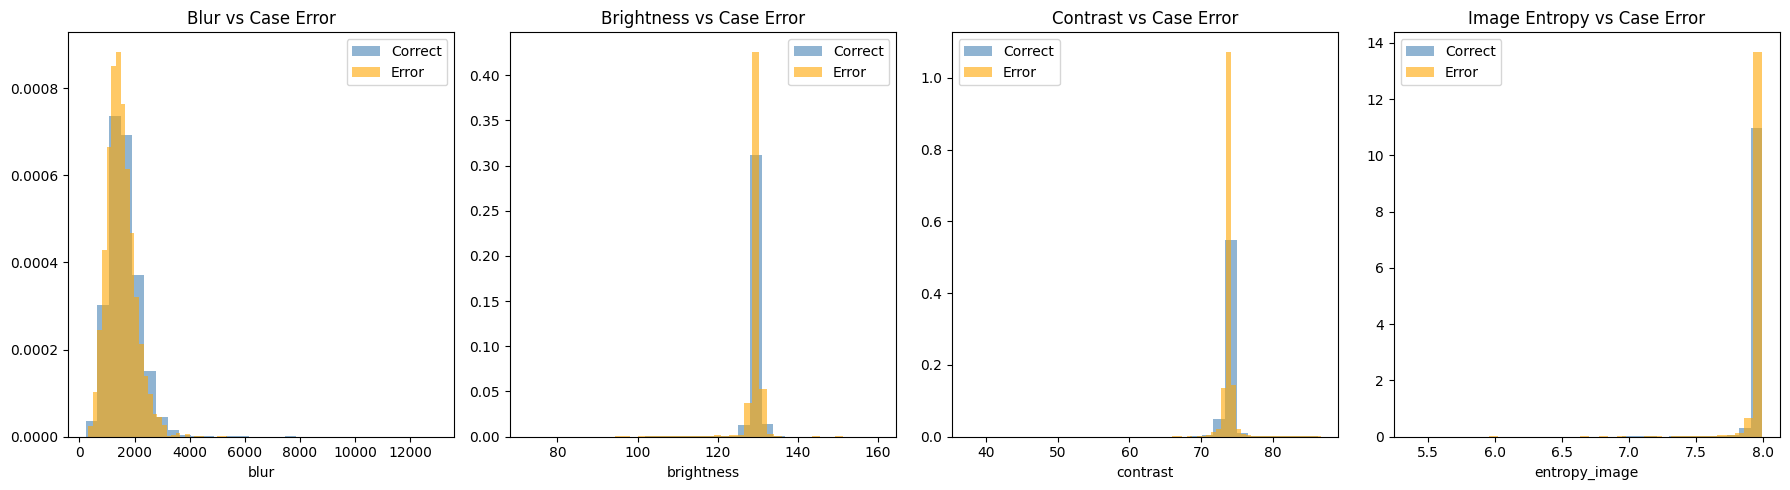

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col, title in zip(axes,
    ["blur", "brightness", "contrast", "entropy_image"],
    ["Blur", "Brightness", "Contrast", "Image Entropy"]):
    for val, label, color in [(0, "Correct", "steelblue"), (1, "Error", "orange")]:
        subset = case_df[case_df["is_error_case"] == val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f"{title} vs Case Error")
    ax.set_xlabel(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [43]:
feature_sets = {
    "maxprob_only":           ["max_prob"],
    "absmargin_only":         ["abs_max_margin"],
    "maxprob_plus_absmargin": ["max_prob", "abs_max_margin"],
    "quality_only":           ["blur", "brightness", "contrast", "entropy_image"],
    "maxprob_plus_quality":   ["max_prob", "blur", "brightness", "contrast", "entropy_image"],
    "all_features":           ["max_prob", "abs_max_margin", "blur", "brightness",
                               "contrast", "entropy_image"],
}

results = []
for name, feats in feature_sets.items():
    X = case_df[feats].copy().fillna(0)
    y = case_df["is_error_case"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                               random_state=42, stratify=y)
    mdl = LogisticRegression(max_iter=1000)
    mdl.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, mdl.predict_proba(X_te)[:, 1])
    results.append({"feature_set": name, "AUROC": round(auc, 4)})

result_df = pd.DataFrame(results).sort_values("AUROC", ascending=False).reset_index(drop=True)
display(result_df)

,feature_set,AUROC
0,maxprob_only,0.8215
1,maxprob_plus_absmargin,0.8211
2,all_features,0.8207
3,maxprob_plus_quality,0.8207
4,absmargin_only,0.8113
5,quality_only,0.5909


mean max_prob for correct cases: 0.7125
mean max_prob for error cases:   0.3518


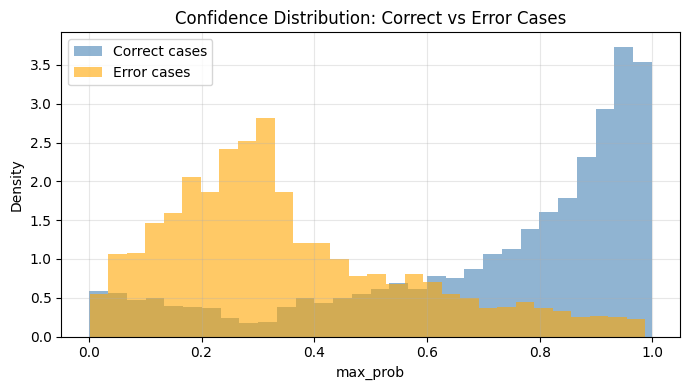

In [44]:
correct_mask = case_df["is_error_case"] == 0
error_mask = case_df["is_error_case"] == 1

print(f"mean max_prob for correct cases: {case_df.loc[correct_mask, 'max_prob'].mean():.4f}")
print(f"mean max_prob for error cases:   {case_df.loc[error_mask,   'max_prob'].mean():.4f}")


plt.figure(figsize=(7, 4))
plt.hist(case_df.loc[correct_mask, "max_prob"], bins=30, alpha=0.6,
         density=True, label="Correct cases", color="steelblue")
plt.hist(case_df.loc[error_mask, "max_prob"], bins=30, alpha=0.6,
         density=True, label="Error cases", color="orange")
plt.xlabel("max_prob")
plt.ylabel("Density")
plt.title("Confidence Distribution: Correct vs Error Cases")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

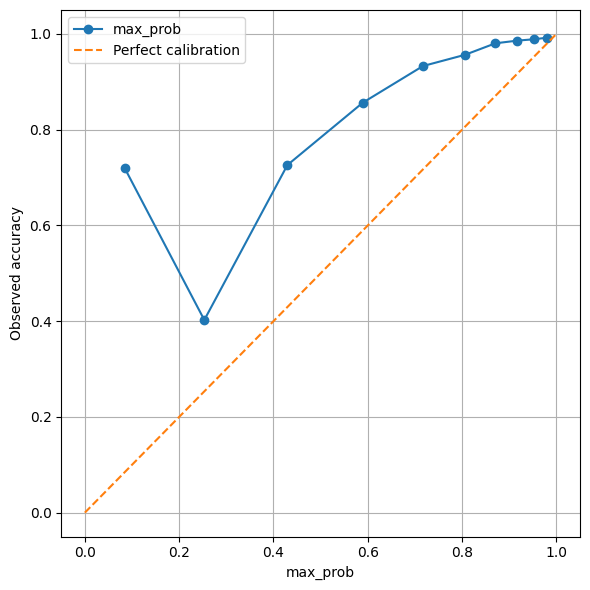

In [45]:
confidence = case_df["max_prob"].values
correct = (case_df["is_error_case"] == 0).astype(int).values

prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="max_prob")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.xlabel("max_prob")
plt.ylabel("Observed accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


bins = np.linspace(0, 1, 11)
binids = np.digitize(confidence, bins) - 1
ece = sum(
    (np.sum(binids == b) / len(confidence)) * abs(
        correct[binids == b].mean() - confidence[binids == b].mean()
    )
    for b in range(10) if np.sum(binids == b) > 0
)

In [47]:
X_reliability = pd.DataFrame(case_df["max_prob"].values, columns=["max_prob"])
y_reliability = case_df["is_error_case"].values

reliability_model = LogisticRegression(max_iter=1000)
reliability_model.fit(X_reliability, y_reliability)

train_preds = reliability_model.predict_proba(X_reliability)[:, 1]
train_auc = roc_auc_score(y_reliability, train_preds)
print(f"AUROC: {train_auc:.4f}")

joblib.dump(reliability_model, "maxprob_reliability_model.pkl")

AUROC: 0.8295


['maxprob_reliability_model.pkl']